# 04: Logistic Regression Baseline (2025 SHED)

A population-weighted logistic regression that predicts `financially_fragile` (could **not** cover a $400 emergency expense with cash or its equivalent). This is the baseline the October models (tree-based and gradient-boosted) have to beat.

**Input:** `data/processed/model_dataset_2025.csv` and its spec, from `03_build_model_dataset.ipynb`. The target, features, survey weight, train/test split and CV folds all come from there.

**What this notebook does:**
1. Scores two reference baselines the brief requires every model to beat: majority class and weighted random
2. Tunes the regularisation strength `C` on the shared 5 CV folds (training rows only)
3. Refits on all training rows and evaluates the final models on the test set: ROC AUC, PR AUC, Brier score, calibration
4. Audits recall and calibration by subgroup
5. Shows which features push predictions up or down
6. Checks how much the model relies on the emergency-savings (EF) questions

All metrics are **population-weighted** with `weight_pop`, so they describe U.S. adults rather than the survey panel.

## 1. Imports and configuration

In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

## Load the model dataset

Run **one** of the two cells below: 2.1 (a) when running locally, 2.1 (b) in Colab (upload both files from `data/processed/`).

In [3]:
# 2.1 (a) Load data files locally
DATASET_PATH = "../data/processed/model_dataset_2025.csv"
JSON_PATH = "../data/processed/model_dataset_2025_spec.json"

In [ ]:
# 2.1 (b) Load data files on Colab
from google.colab import files

files.upload()  # model_dataset_2025.csv and model_dataset_2025_spec.json

DATASET_PATH = "../content/model_dataset_2025.csv"
JSON_PATH = "../content/model_dataset_2025_spec.json"

In [5]:
data = pd.read_csv(DATASET_PATH, low_memory=False)
with open(JSON_PATH, encoding="utf-8") as f:
    spec = json.load(f)

TARGET = spec["target"]["column"]
WEIGHT = spec["weight"]

print(f"Rows: {data.shape[0]:,}\nColumns: {data.shape[1]:,}")
print(f"Target: {TARGET}  ({spec['target']['definition']})")

Rows: 12,934
Columns: 430
Target: financially_fragile  (1 if pay_casheqv == 'No', else 0)


In [6]:
RANDOM_STATE = 42

# Regularisation strengths to try (smaller C = stronger regularisation)
C_GRID = [0.003, 0.01, 0.03, 0.1, 0.3, 1.0]

# Probability above which a respondent is labelled "fragile" for recall / precision.
# ROC AUC, PR AUC and Brier score don't depend on it.
THRESHOLD = 0.5
MISSING = "__MISSING__"

## Features and train/test split

- `sample_weight_train` is `weight_pop` rescaled to mean 1. It's what the model is fitted with: sklearn's `C` interacts with the total weight, so raw population weights (tens of thousands each) would effectively switch regularisation off
- `w_train` / `w_test` are the raw weights, used for population-weighted metrics
- Model choices use training rows only. The test set is used only for final evaluation of the with-EF and without-EF models

In [7]:
# Get all the features we would use for our baseline model
NUMERIC_FEATURES = spec["features"]["numeric"]
CATEGORICAL_FEATURES = spec["features"]["categorical"]
ORDINAL_FEATURES = spec["features"]["ordinal"]

# I thought EF variables would cause leakage but it might not as well.
# So, I made two different feature matrices, one with EF and one without EF
FEATURES_WITH_EF = NUMERIC_FEATURES + CATEGORICAL_FEATURES + ORDINAL_FEATURES
FEATURES_NO_EF = [col for col in FEATURES_WITH_EF if col not in spec["ef_module"]]

# Same as defined in 03
train = data[data["split"] == "train"]
test = data[data["split"] == "test"]

In [8]:
# Our first modei will be on the feature matrix with EF modules.
X_train, y_train, w_train = train[FEATURES_WITH_EF], train[TARGET], train[WEIGHT]
X_test, y_test, w_test = test[FEATURES_WITH_EF], test[TARGET], test[WEIGHT]

sample_weight_train = w_train / w_train.mean()
cv_fold_train = train["cv_fold"]

print(f"Features with EF: {len(FEATURES_WITH_EF)}")
print(f"Features without EF: {len(FEATURES_NO_EF)}")
print(f"Train: {len(train):,} rows, weighted fragile rate {np.average(y_train, weights=w_train):.1%}")
print(f"Test:  {len(test):,} rows, weighted fragile rate {np.average(y_test, weights=w_test):.1%}")

Features with EF: 425
Features without EF: 409
Train: 10,347 rows, weighted fragile rate 36.8%
Test:  2,587 rows, weighted fragile rate 37.0%


## Model pipeline and metrics

**Preprocessing** is fitted inside the pipeline, so it only ever learns from the rows the model is trained on:
- **Numeric:** I decided to fill missing numbers with the training-set median; and add a column that the value was missing; then I standardized them.
- **Categorical:** One-hot encoded and made a category for missing answers.
- **Ordinal:** Ordinal encoded and then standardized them

**Model:** L2-regularised logistic regression

**Metrics** (all weighted by `weight_pop`):

| Metric | What it tells you | Better |
|---|---|---|
| ROC AUC | How well the model ranks fragile respondents above non-fragile ones | Higher (0.5 = chance) |
| PR AUC | Precision-recall trade-off for the fragile class | Higher (chance = the fragile rate, about 0.37) |
| Brier score | Mean squared error of the probabilities; rewards calibration | Lower |
| Accuracy, recall, precision, F1 | Classification quality at the 0.5 threshold | Higher |

In [9]:
# Do all the imputations

def build_preprocessor(features):
    numeric = [col for col in NUMERIC_FEATURES if col in features]
    categorical = [col for col in CATEGORICAL_FEATURES if col in features]
    ordinal = [col for col in ORDINAL_FEATURES if col in features]

    # Get the order for the ordinal features
    ORDINAL_ORDER = spec["features"]["ordinal_order"]

    numeric_pipeline = Pipeline([
        ("impute", SimpleImputer(strategy="median", add_indicator=True)),
        ("scale", StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ("impute", SimpleImputer(strategy="constant", fill_value=MISSING)),
        ("one_hot", OneHotEncoder(handle_unknown="ignore")),
    ])
    ordinal_pipeline = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", OrdinalEncoder(categories=[ORDINAL_ORDER[col] for col in ordinal])),
        ("scale", StandardScaler()),
    ])

    return ColumnTransformer([
        ("numeric", numeric_pipeline, numeric),
        ("categorical", categorical_pipeline, categorical),
        ("ordinal", ordinal_pipeline, ordinal),
    ])

In [10]:
def build_model(C, features):
    return Pipeline([
        ("preprocess", build_preprocessor(features)),
        ("model", LogisticRegression(C=C, max_iter=1000)),
    ])

In [11]:
def evaluate(y_true, p_fragile, weights, threshold=THRESHOLD):
    """Population-weighted metrics for predicted probabilities of being fragile."""
    y_pred = (np.asarray(p_fragile) >= threshold).astype(int)
    return {
        "ROC AUC": roc_auc_score(y_true, p_fragile, sample_weight=weights),
        "PR AUC": average_precision_score(y_true, p_fragile, sample_weight=weights),
        "Brier": brier_score_loss(y_true, p_fragile, sample_weight=weights),
        "Accuracy": accuracy_score(y_true, y_pred, sample_weight=weights),
        "Recall": recall_score(y_true, y_pred, sample_weight=weights, zero_division=0),
        "Precision": precision_score(y_true, y_pred, sample_weight=weights, zero_division=0),
        "F1": f1_score(y_true, y_pred, sample_weight=weights, zero_division=0),
    }

## Reference baselines

The challenege project overview asks every model to beat two baselines:

- **Majority class:** always predicts the most common outcome in training (not fragile). Its accuracy looks decent (about 63%) but it never finds a single fragile household, so recall is 0
- **Weighted random:** guesses "fragile" at random, as often as fragility actually occurs in the training population (about 37% of the time). It has no information, so its ROC AUC sits near 0.5

In [12]:
train_fragile_rate = np.average(y_train, weights=w_train)
majority_class = int(train_fragile_rate >= 0.5)

rng = np.random.default_rng(RANDOM_STATE)

baseline_predictions = {
    "Majority class": np.full(len(y_test), float(majority_class)),
    "Weighted random": (rng.random(len(y_test)) < train_fragile_rate).astype(float),
}

baseline_results = pd.DataFrame({
    name: evaluate(y_test, p, w_test) for name, p in baseline_predictions.items()
}).T

display(baseline_results.round(3))

,ROC AUC,PR AUC,Brier,Accuracy,Recall,Precision,F1
Majority class,0.500,0.370,0.370,0.630,0.000,0.000,0.00
Weighted random,0.492,0.367,0.473,0.527,0.358,0.361,0.36


## Tune regularisation on the shared CV folds

We try each value of `C` using the five existing cross-validation folds. For each fold, the model trains on the other four folds and predicts the held-out fold. We compare values of C using population-weighted log loss and select the one with the lowest average log loss.

In [13]:
def tune_regularization(features):
    fold_scores = []
    number_of_folds = spec["cv"]["n_folds"]

    for c_value in C_GRID:
        for fold in range(number_of_folds):
            training_rows = cv_fold_train != fold
            validation_rows = cv_fold_train == fold

            model = build_model(c_value, features)

            model.fit(
                X_train.loc[training_rows, features],
                y_train.loc[training_rows],
                model__sample_weight=sample_weight_train.loc[training_rows],
            )

            predicted_probabilities = model.predict_proba(
                X_train.loc[validation_rows, features]
            )[:, 1]

            fold_scores.append({
                "C": c_value,
                "fold": fold,
                "log_loss": log_loss(
                    y_train.loc[validation_rows],
                    predicted_probabilities,
                    sample_weight=w_train.loc[validation_rows],
                ),
                "roc_auc": roc_auc_score(
                    y_train.loc[validation_rows],
                    predicted_probabilities,
                    sample_weight=w_train.loc[validation_rows],
                ),
            })

    results_by_c = (
        pd.DataFrame(fold_scores)
        .groupby("C")
        .agg(
            mean_log_loss=("log_loss", "mean"),
            log_loss_sd=("log_loss", "std"),
            mean_roc_auc=("roc_auc", "mean"),
            roc_auc_sd=("roc_auc", "std"),
        )
    )

    best_c = results_by_c["mean_log_loss"].idxmin()

    return results_by_c, best_c

In [14]:
cv_results_with_ef, best_c_with_ef = tune_regularization(FEATURES_WITH_EF)

display(cv_results_with_ef.round(4))
print(f"Selected C for the model with EF questions: {best_c_with_ef}")

,mean_log_loss,log_loss_sd,mean_roc_auc,roc_auc_sd
C,,,,
0.003,0.3357,0.0129,0.9257,0.0073
0.010,0.3321,0.0138,0.9267,0.0070
0.030,0.3377,0.0150,0.9248,0.0070
0.100,0.3532,0.0165,0.9205,0.0070
0.300,0.3730,0.0172,0.9161,0.0067
1.000,0.3979,0.0187,0.9109,0.0063


Selected C for the model with EF questions: 0.01


## Fit on all training rows and evaluate on the test set

This evaluates the main model with the EF questions. The sensitivity analysis at the end tests a second model, the model without the EFs.

In [15]:
final_model = build_model(best_c_with_ef, FEATURES_WITH_EF)
final_model.fit(X_train[FEATURES_WITH_EF], y_train, model__sample_weight=sample_weight_train)

p_test = pd.Series(
    final_model.predict_proba(X_test[FEATURES_WITH_EF])[:, 1],
    index=X_test.index,
    name="p_fragile",
)

results = pd.concat([
    baseline_results,
    pd.DataFrame({"Logistic regression (with EF)": evaluate(y_test, p_test, w_test)}).T,
])

display(results.round(3))

,ROC AUC,PR AUC,Brier,Accuracy,Recall,Precision,F1
Majority class,0.500,0.370,0.370,0.630,0.000,0.000,0.00
Weighted random,0.492,0.367,0.473,0.527,0.358,0.361,0.36
Logistic regression (with EF),0.925,0.875,0.103,0.856,0.780,0.821,0.80


### ROC and precision-recall curves

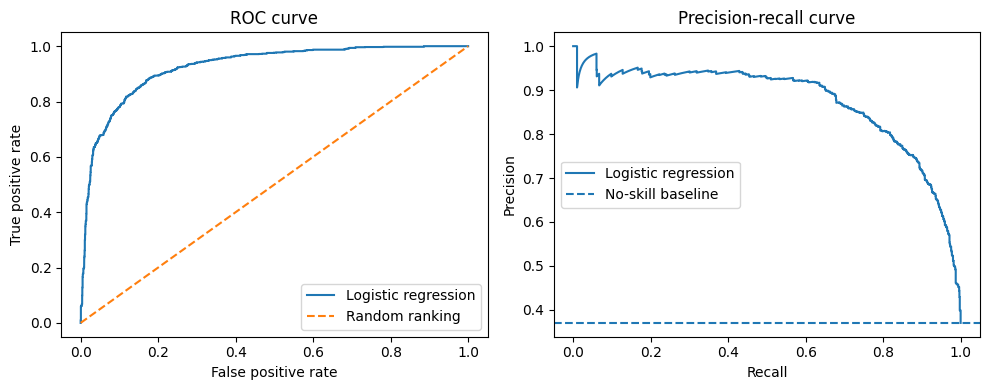

In [16]:
test_fragile_rate = np.average(y_test, weights=w_test)

fpr, tpr, _ = roc_curve(y_test, p_test, sample_weight=w_test)

precision, recall, _ = precision_recall_curve(y_test, p_test, sample_weight=w_test)

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(10, 4))

# ROC curve
ax_roc.plot(fpr, tpr, label="Logistic regression")
ax_roc.plot([0, 1], [0, 1], "--", label="Random ranking")
ax_roc.set(
    title="ROC curve",
    xlabel="False positive rate",
    ylabel="True positive rate",
)
ax_roc.legend()

# Precision-recall curve
ax_pr.plot(recall, precision, label="Logistic regression")
ax_pr.axhline(
    test_fragile_rate,
    linestyle="--",
    label="No-skill baseline",
)
ax_pr.set(
    title="Precision-recall curve",
    xlabel="Recall",
    ylabel="Precision",
)
ax_pr.legend()

fig.tight_layout()
plt.show()

### Calibration

Calibration measures whether the model’s predicted probabilities agree with observed outcomes. For example, among respondents assigned a predicted fragility probability of approximately 30%, about 30% should actually be financially fragile.

To assess this, test-set predictions are divided into 10 approximately equal-sized groups, ordered from lowest to highest predicted probability. For each group, we compare the average predicted probability with the survey-weighted observed fragility rate. A well-calibrated model will produce points close to the 45-degree reference line. Points above the line indicate underprediction, while points below it indicate overprediction.

The bins are calculated manually because scikit-learn’s `calibration_curve` function does not support survey weights.

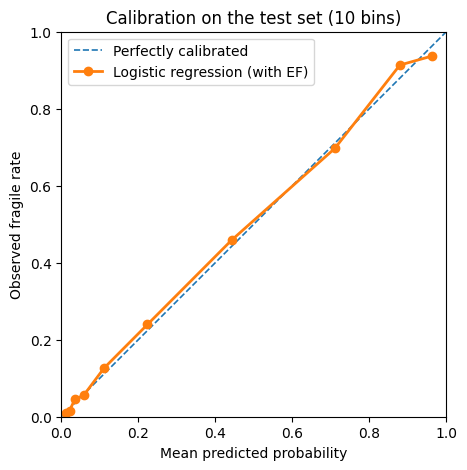

,mean_predicted,observed_rate,rows
0,0.012,0.009,259
1,0.022,0.016,259
2,0.036,0.046,258
3,0.058,0.055,259
4,0.111,0.126,259
5,0.224,0.240,258
6,0.442,0.458,259
7,0.710,0.697,258
8,0.880,0.913,259
9,0.963,0.937,259


Expected calibration error: 0.015  (average gap between predicted and observed, in probability points)


In [17]:
def weighted_calibration(y_true, p, weights, n_bins=10):
    frame = pd.DataFrame({
        "bin": pd.qcut(p, q=n_bins, duplicates="drop"),
        "w": weights,
        "wp": p * weights,
        "wy": y_true * weights,
    })
    sums = frame.groupby("bin", observed=True)[["w", "wp", "wy"]].sum()
    table = pd.DataFrame({
        "mean_predicted": sums["wp"] / sums["w"],
        "observed_rate": sums["wy"] / sums["w"],
        "rows": frame.groupby("bin", observed=True).size(),
    }).reset_index(drop=True)
    # Weighted average gap between predicted and observed (expected calibration error)
    ece = np.average((table["mean_predicted"] - table["observed_rate"]).abs(), weights=sums["w"].to_numpy())
    return table, ece


calibration_table, ece = weighted_calibration(y_test, p_test, w_test)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], linewidth=1.2, linestyle="--", label="Perfectly calibrated")
ax.plot(calibration_table["mean_predicted"], calibration_table["observed_rate"],
        linewidth=2, marker="o", markersize=6, label="Logistic regression (with EF)")
ax.set(title="Calibration on the test set (10 bins)", xlabel="Mean predicted probability",
       ylabel="Observed fragile rate", xlim=(0, 1), ylim=(0, 1))
ax.set_aspect("equal")
ax.legend(loc="upper left")
plt.show()

display(calibration_table.round(3))
print(f"Expected calibration error: {ece:.3f}  (average gap between predicted and observed, in probability points)")

### Confusion matrix at the 0.5 threshold

Counts are respondents in the test set (unweighted), so they're easy to read. The percentages are population-weighted.

In [18]:
predicted = (p_test >= THRESHOLD).map({True: "Predicted fragile", False: "Predicted not fragile"})
actual = y_test.map({1: "Actually fragile", 0: "Actually not fragile"})

counts = pd.crosstab(actual, predicted)
weighted_share = pd.crosstab(actual, predicted, values=w_test, aggfunc="sum", normalize=True)

display(counts)
display((weighted_share * 100).round(1).astype(str) + "%")

p_fragile,Predicted fragile,Predicted not fragile
financially_fragile,,
Actually fragile,697,210
Actually not fragile,148,1532


p_fragile,Predicted fragile,Predicted not fragile
financially_fragile,,
Actually fragile,28.9%,8.2%
Actually not fragile,6.3%,56.7%


## Subgroup audit

This section evaluates model performance across demographic groups in the test set. Its purpose is to identify whether the model makes systematically different errors for certain groups, not to use demographic characteristics for targeting or decision-making.

For each group, we examine:
- Predicted versus observed fragility rate: A large difference indicates that the model may be overpredicting or underpredicting financial fragility for that group.
- Recall: Among respondents who are actually financially fragile, the proportion correctly identified by the model.
- Sample size: Results for groups with fewer than 100 test respondents are labeled `small` because estimates based on limited samples may be unstable.

The dataset includes multiple variables that represent similar demographic characteristics. To avoid reporting the same attribute more than once, the audit uses one selected variable for each characteristic.

`__NOT_ASKED__` in `pppa_lgb` is not a sexual-orientation group. It is the respondents who were never asked that question.

In [19]:
AUDIT_COLUMNS = ["race_5cat", "ppgender", "ppagecat", "pppa_lgb"]
SMALL_GROUP = 100

audit_rows = []
for column in AUDIT_COLUMNS:
    for group, index in test.groupby(column).groups.items():
        yt, pt, wt = y_test.loc[index], p_test.loc[index], w_test.loc[index]
        both_classes = yt.nunique() == 2
        audit_rows.append({
            "attribute": column,
            "group": group,
            "rows": len(index),
            "actual fragile rate": np.average(yt, weights=wt),
            "predicted fragile rate": np.average(pt, weights=wt),
            "recall": recall_score(yt, pt >= THRESHOLD, sample_weight=wt, zero_division=0) if yt.sum() else np.nan,
            "ROC AUC": roc_auc_score(yt, pt, sample_weight=wt) if both_classes else np.nan,
            "Brier": brier_score_loss(yt, pt, sample_weight=wt),
            "note": "small" if len(index) < SMALL_GROUP else "",
        })

audit = pd.DataFrame(audit_rows)
audit["gap (pred - actual)"] = audit["predicted fragile rate"] - audit["actual fragile rate"]

overall = evaluate(y_test, p_test, w_test)
print(f"Overall: recall {overall['Recall']:.3f}, ROC AUC {overall['ROC AUC']:.3f}, Brier {overall['Brier']:.3f}\n")
display(audit.set_index(["attribute", "group"]).round(3))

Overall: recall 0.780, ROC AUC 0.925, Brier 0.103



rows  actual fragile rate  \
attribute group                                                   
race_5cat Asian                        142                0.236   
          Black                        319                0.633   
          Hispanic                     339                0.505   
          Other                         64                0.686   
          White                       1723                0.277   
ppgender  Female                      1272                0.391   
          Male                        1315                0.350   
ppagecat  18-24                        208                0.566   
          25-34                        355                0.480   
          35-44                        435                0.474   
          45-54                        364                0.350   
          55-64                        492                0.281   
          65-74                        444                0.216   
          75+                          289                0.168   
pppa_lgb  Bisexual                      73                0.527   
          Gay or lesbian                75                0.434   
          Something else                53                0.602   
          Straight, that is, not gay  2137                0.344   
          __NOT_ASKED__                249                0.475   

                                      predicted fragile rate  recall  ROC AUC  \
attribute group                                                                 
race_5cat Asian                                        0.225   0.675    0.916   
          Black                                        0.610   0.844    0.853   
          Hispanic                                     0.537   0.887    0.928   
          Other                                        0.622   0.823    0.867   
          White                                        0.269   0.696    0.923   
ppgender  Female                                       0.381   0.790    0.931   
          Male                                         0.352   0.768    0.919   
ppagecat  18-24                                        0.577   0.839    0.883   
          25-34                                        0.473   0.825    0.932   
          35-44                                        0.462   0.833    0.903   
          45-54                                        0.329   0.750    0.942   
          55-64                                        0.273   0.689    0.924   
          65-74                                        0.231   0.674    0.911   
          75+                                          0.174   0.595    0.913   
pppa_lgb  Bisexual                                     0.527   0.803    0.828   
          Gay or lesbian                               0.417   0.807    0.970   
          Something else                               0.590   0.945    0.907   
          Straight, that is, not gay                   0.340   0.757    0.925   
          __NOT_ASKED__                                0.474   0.859    0.924   

                                      Brier   note  gap (pred - actual)  
attribute group                                                          
race_5cat Asian                       0.092                      -0.011  
          Black                       0.148                      -0.023  
          Hispanic                    0.106                       0.032  
          Other                       0.130  small               -0.064  
          White                       0.092                      -0.007  
ppgender  Female                      0.102                      -0.010  
          Male                        0.103                       0.002  
ppagecat  18-24                       0.135                       0.011  
          25-34                       0.101                      -0.007  
          35-44                       0.123                      -0.012  
          45-54                       0.

## What drives the predictions

This section examines the fitted logistic regression coefficients. Positive coefficients are associated with a higher predicted probability of financial fragility, while negative coefficients are associated with a lower predicted probability.

Numeric and ordinal features were standardized, so their coefficient shows how much the log-odds of being fragile change when that feature goes up by one standard deviation (one typical step).

For one-hot features, every answer to a question gets its own column, and no answer is left out as a reference point. So a coefficient does not compare an answer to one "default" answer. Instead, it shows how much giving that answer pushes the prediction up or down compared with an average respondent.

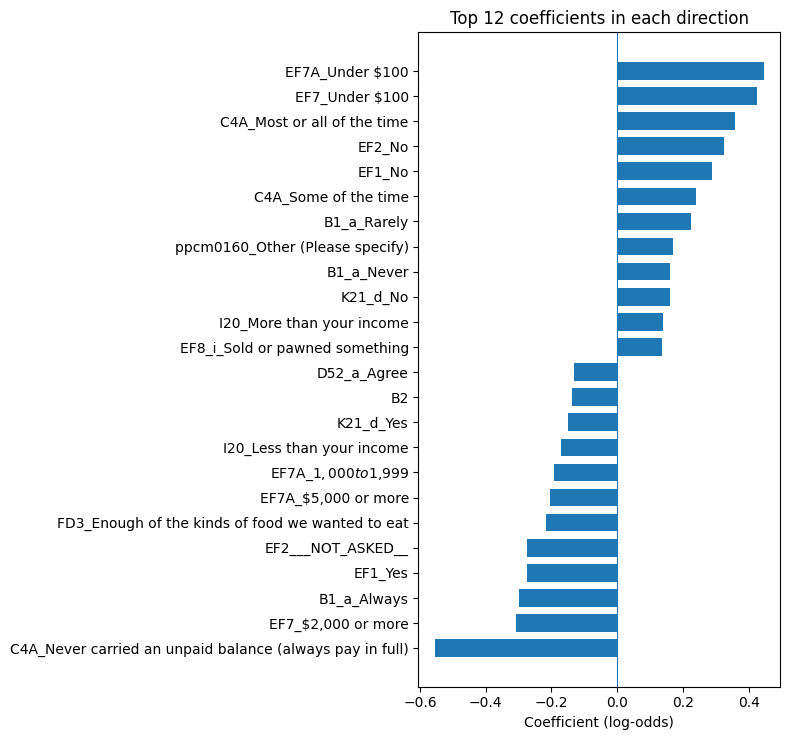

In [43]:
feature_names = [
    name.split("__", 1)[1]
    for name in final_model.named_steps["preprocess"].get_feature_names_out()
]
coefficients = pd.Series(final_model.named_steps["model"].coef_[0], index=feature_names, name="coefficient")

TOP_N = 12
top = pd.concat([coefficients.nlargest(TOP_N), coefficients.nsmallest(TOP_N)]).sort_values()

fig, ax = plt.subplots(figsize=(8, 7.5))
ax.barh(top.index, top.values, height=0.7)
ax.axvline(0, linewidth=0.8)
ax.set(title=f"Top {TOP_N} coefficients in each direction", xlabel="Coefficient (log-odds)")
fig.tight_layout()
plt.show()

## Sensitivity analysis: without the emergency-savings questions

`EF1`, `EF2`, `EF8_*` and the other EF questions aren't derived from the target, but they're very close to it. This sensitivity model removes them and tunes its own `C` on the same training folds. The comparison shows how much of the main model's performance comes from those near-proxy questions and how much comes from broader information such as income, employment, demographics and other financial behaviour.

In [44]:
cv_results_no_ef, BEST_C_NO_EF = tune_regularization(FEATURES_NO_EF)
display(cv_results_no_ef.round(4))
print(f"Best C without EF (lowest CV log loss): {BEST_C_NO_EF}")

sensitivity_model = build_model(BEST_C_NO_EF, FEATURES_NO_EF)
sensitivity_model.fit(X_train[FEATURES_NO_EF], y_train, model__sample_weight=sample_weight_train)
p_test_no_ef = sensitivity_model.predict_proba(X_test[FEATURES_NO_EF])[:, 1]

results.loc["Logistic regression (without EF)"] = evaluate(y_test, p_test_no_ef, w_test)
display(results.round(3))

comparison = results.loc[["Logistic regression (with EF)", "Logistic regression (without EF)"]]
display(comparison.round(3))

,mean_log_loss,log_loss_sd,mean_roc_auc,roc_auc_sd
C,,,,
0.003,0.3570,0.0124,0.9154,0.0072
0.010,0.3548,0.0142,0.9158,0.0071
0.030,0.3623,0.0158,0.9130,0.0071
0.100,0.3783,0.0180,0.9082,0.0073
0.300,0.3969,0.0206,0.9035,0.0074
1.000,0.4194,0.0245,0.8982,0.0076


Best C without EF (lowest CV log loss): 0.01


,ROC AUC,PR AUC,Brier,Accuracy,Recall,Precision,F1
Majority class,0.500,0.370,0.370,0.630,0.000,0.000,0.000
Weighted random,0.492,0.367,0.473,0.527,0.358,0.361,0.360
Logistic regression (with EF),0.925,0.875,0.103,0.856,0.780,0.821,0.800
Logistic regression (without EF),0.914,0.855,0.112,0.845,0.768,0.805,0.786


,ROC AUC,PR AUC,Brier,Accuracy,Recall,Precision,F1
Logistic regression (with EF),0.925,0.875,0.103,0.856,0.780,0.821,0.800
Logistic regression (without EF),0.914,0.855,0.112,0.845,0.768,0.805,0.786


## Summary

### ROC-AUC Scores
The logistic regression with EF questions substantially outperforms both baselines. Its ROC AUC is 0.925, meaning it has strong ability to rank fragile respondents above non-fragile respondents. Its PR AUC is 0.875, compared with a no-skill level near the 37.0% fragile rate, showing that it maintains high precision while identifying much of the fragile population. Its Brier score is 0.103; because lower values indicate more accurate probabilities, this is a large improvement over the majority baseline's 0.370. At the 0.50 classification threshold, the model has 85.6% accuracy, 78.0% recall, 82.1% precision, and an F1 score of 0.800. In practical terms, it identifies about 78 of every 100 fragile adults, and about 82 of every 100 adults it flags are actually fragile.

### Confusion Matrix
The confusion matrix gives the same result in population terms. The model correctly classifies 28.9% of the population as fragile and 56.7% as not fragile. It misses 8.2% of the population who are actually fragile and incorrectly flags 6.3% who are not fragile. The corresponding unweighted respondent counts are 697 true positives, 1,532 true negatives, 210 false negatives, and 148 false positives. These classifications depend on the selected 0.50 threshold; changing the threshold would change recall and precision, but not ROC AUC, PR AUC, or Brier score.

### Calibration Curve
The model is also well calibrated overall. Its expected calibration error is 0.015, meaning that the average difference between predicted probability and observed fragility across the 10 probability groups is about 1.5 percentage points. For example, the group with an average prediction of 44.2% had an observed weighted fragility rate of 45.8%. The group with an average prediction of 88.0% had an observed rate of 91.3%. The small gaps across the calibration table indicate that the probabilities can generally be interpreted as population risk estimates, although calibration should still be monitored in future data.

### Sensitivity Analysis
The sensitivity analysis checks whether the model depends too much on the EF questions, which are very close to the question we're predicting. Removing them lowers ROC AUC from 0.925 to 0.914, PR AUC from 0.875 to 0.855 and F1 from 0.800 to 0.786, and raises the Brier score from 0.103 to 0.112. Every metric gets a little worse, but only a little. So the EF questions help, but the model does not need them to work well.

This does not mean the rest of the model runs only on income, jobs and demographics. Other questions that directly ask about money struggles are still included. For example, `B2` asks people whether they are "finding it difficult to get by," and on its own it sorts 79% of respondents correctly. Comparing the top coefficients of the two models would show which questions take over once the EF module is gone.

### TL:DR
Overall, logistic regression is a strong baseline for this project: it clearly beats the required reference models, ranks respondents well, produces reasonably calibrated probabilities, and remains effective without the EF module. Its main limitations are lower recall in groups where fragility is less common, weaker ranking for Black respondents, noisy results for small groups, results that depend on the 0.50 cutoff, and coefficients that show patterns rather than causes.